In [1]:
import numpy as np
import pandas as pd
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers

2024-01-31 10:22:01.191834: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-01-31 10:22:16.253284: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-01-31 10:22:16.270741: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-01-31 10:22:51.893812: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
name_file = "dataset_full.csv"
dataset = pd.read_csv(name_file)

In [3]:
test_dataset = dataset.sample(frac=0.2)
train_dataset = dataset[~dataset.isin(test_dataset)].dropna()
test_labels = test_dataset.pop('phishing')
train_labels = train_dataset.pop('phishing')

In [23]:
normalizer = layers.experimental.preprocessing.Normalization()
normalizer.adapt(np.array(train_dataset))

model = keras.Sequential([
    normalizer,
    # layers.Dense(32),
    layers.Dense(16),
    layers.Dense(4),
    # layers.Dropout(.2),
    layers.Dense(1, activation='sigmoid'),
])

In [24]:
model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.build()

In [25]:
history = model.fit(
    train_dataset,
    train_labels,
    epochs=20,
    validation_split=0.8,
    verbose=0, # disable logging
)

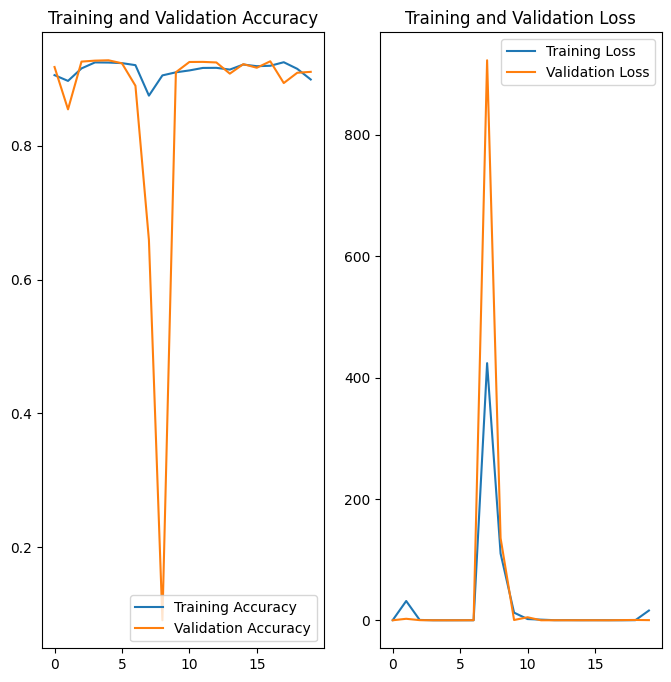

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [27]:
tab = model.predict(test_dataset)

print(tab)
tab = np.round(tab)

print(tab)
bon = 0
mauvais = 0
damien = []
for i, j in zip(tab, test_labels):
    if i == j:
        bon += 1
    else:
        mauvais += 1
        damien.append(i)

print(f'bon = {bon}')
print(f'mauvais = {mauvais}')

print(damien.count(1))
print(100 - mauvais/bon*100)

555/555 [==============================] - 0s 759us/step
[[4.1487361e-05]
 [1.4095963e-05]
 [9.9997407e-01]
 ...
 [3.0659027e-08]
 [3.1149826e-05]
 [5.6453487e-06]]
[[0.]
 [0.]
 [1.]
 ...
 [0.]
 [0.]
 [0.]]
bon = 16067
mauvais = 1662
833
89.65581626937201
